# Deep Reconstruction of SIRS Model in Julia

This notebook is a Julia implementation of the Python notebook for modeling deep dynamic systems. It covers the following three architectures:
1.  **ResNet**
2.  **Neural Ordinary Differential Equation (Neural ODE)**
3.  **Universal Differential Equation (UDE)**

In [1]:
using DifferentialEquations, DiffEqFlux, Flux, Functors, Optimisers, Plots, BSON, Printf, PlotlyJS
# Plotly backend
plotly()

SyntaxError: invalid syntax (503822546.py, line 1)

## 1. Ground Truth Data 

In [ ]:
function sirs_deriv!(du, u, p, t)
    S, I, R = u
    β, γ, θ, μ = p
    du[1] = -β * S * I + θ * R - μ * S
    du[2] =  β * S * I - γ * I - μ * I
    du[3] =  γ * I - θ * R - μ * R
end

In [ ]:
# True parameters for the ground truth model
γ = 1/7
μ = 1/(80*365)
θ = 1/365
β = 2*(μ + γ)

p_true = Float32[β, γ, θ, μ]
u0      = Float32[0.999, 0.001, 0.0]
tspan   = (0.0f0, 2000.0f0)
tsteps  = 0.0f0:1.0f0:2000.0f0

# Define true solution
prob_true     = ODEProblem(sirs_deriv!, u0, tspan, p_true)
sol_true      = solve(prob_true, Tsit5(), saveat = tsteps)
true_traj     = Array(sol_true)

In [ ]:
# plot the data
Plots.plot(
    tsteps,
    true_traj[2, :], 
    lw=3,
    ls=:solid,
    label="Dati Veri (Infected)",
    title="Confronto Predizioni sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:outertopright,
)

In [ ]:
# calculate second true_traj
β_2 = 10*(μ + γ)

p_true_2 = Float32[β_2, γ, θ, μ]


tspan_2   = (0.0f0, 500.0f0)
tsteps_2  = 0.0f0:1.0f0:500.0f0

# Define true solution
prob_true_2     = ODEProblem(sirs_deriv!, u0, tspan_2, p_true_2)
sol_true_2      = solve(prob_true_2, Tsit5(), saveat = tsteps_2)
true_traj_2     = Array(sol_true_2)

Plots.plot(
    tsteps_2,
    true_traj_2[2, :], 
    lw=3,
    ls=:solid,
    label="Dati Veri (Infected)",
    title="Confronto Predizioni sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:outertopright,
)


In [ ]:
plotlyjs()

# -- Tracce per β = 2
trace_true_1 = PlotlyJS.scatter(x = tsteps, y = true_traj[2, :], mode = "lines", name = "Dati Veri (I)", line = attr(width=3))

# -- Tracce per β = 10
trace_true_2 = PlotlyJS.scatter(x = tsteps_2, y = true_traj_2[2, :], mode = "lines", name = "Dati Veri (I)", line = attr(width=3))

# -- Crea i subplot
fig = PlotlyJS.make_subplots(rows=1, cols=2, subplot_titles=["R₀ = 2" "R₀ = 10"])

# -- Aggiungi le tracce
add_trace!(fig, trace_true_1, row=1, col=1)

add_trace!(fig, trace_true_2, row=1, col=2)


# -- Layout
relayout!(
    fig;
    title_text = "Confronto delle Ricostruzioni del Modello SIRS",
    title_x = 0.5,
    title_font = attr(size=18),
    showlegend = false,
    xaxis_title = "Tempo (giorni)",
    yaxis_title = "Frazione di Infetti",
    template = "plotly_white"
)


# -- Mostra
display(fig)


## 2. ResNet

In [ ]:
# ResNet block
resblock = Flux.Chain(
    Flux.Dense(3, 64, relu),
    Flux.Dense(64, 64, relu),
    Flux.Dense(64, 3)
)

# Define the skip connection
resnet_model(x, m) = x .+ m(x)

# COnverting data to Float32 type so they are easier to train
X = Float32.(true_traj[:, 1:end-1])
Y = Float32.(true_traj[:, 2:end])

opt = ADAM(1e-3)

state = Flux.setup(opt, resblock)

# Loss function (just MSE between predicted and ground truth values)
function loss(m, x, y)
    ŷ = resnet_model(x, m)
    return Flux.Losses.mse(ŷ, y)
end

In [ ]:
# Training loop for ResNet
opt = ADAM(1e-4)

println("Training ResNet…")
for epoch in 1:5000
    gs = gradient(resblock) do m
        loss(m, X, Y)
    end
    Flux.update!(state, resblock, gs[1])

    if epoch % 100 == 0
        @printf("  epoch %d, loss = %.8f\n", epoch, loss(resblock, X, Y))
    end
end
print("Training completed")

In [ ]:
# --- Save ResNet Model ---
# filepath = "deep_models_julia/2 resnet LOSS $(round(loss(resblock, X, Y), digits=8)) EPOCH 15000.bson"
# BSON.bson(filepath, Dict("model" => resblock))
# println("ResNet model saved to $(filepath) ")

filepath = "deep_models_julia/2 resnet LOSS 0.0 EPOCH 15000.bson"
loaded_data = BSON.load(filepath)
resblock = loaded_data["model"]

## 3. Neural Ordinary Differential Equations (Neural ODE)

In [ ]:
# Define the NeuralODE model
neural_ode_func = Flux.Chain(
  Flux.Dense(3, 16, tanh),
  Flux.Dense(16, 16, tanh),
  Flux.Dense(16, 3)
)

p, st = Flux.destructure(neural_ode_func)

opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p)

# The method helps to reconstruct the ODE system from the neural network
function reconstruct_sirs(du, u, p, t)
    curr_deriv = st(p)(u)
    du[1] = curr_deriv[1]
    du[2] = curr_deriv[2]
    du[3] = curr_deriv[3]
end

# Method to predict the trajectory using the neural ODE
function predict_neural_ode(p)
    return Array(solve(n_ode, 
            Rodas5(), 
            p=p, 
            saveat=tsteps, 
            sensealg=InterpolatingAdjoint(
                autojacvec=ReverseDiffVJP(true)
                )
            ))
end

function loss_neural(p)
    pred_sol = predict_neural_ode(p)
    loss = Flux.Losses.mse(pred_sol, true_traj)
    return loss
end

# Define the ODE problem
n_ode = ODEProblem(
    reconstruct_sirs,
    u0,
    tspan,
    p  
)

In [ ]:
# Training loop for the Neural ODE
println("Training Neural ODE…")
opt = Optimisers.Adam(1e-3)

for epoch in 1:1000
    grads = gradient(loss_neural, p)[1]

    # Update the parameters using the optimizer
    state, p = Optimisers.update(state, p, grads)
    
    if epoch % 10 == 0
        current_loss = loss_neural(p)
        println("Epoch $epoch | Loss = ", current_loss)
        if current_loss < 0.005
            break
        end
    end
end

In [ ]:
# --- Save Neural ODE Parameters ---
filepath = "deep_models_julia/2 node LOSS $(round(loss_neural(p), digits=6)) EPOCH 6000.bson"
BSON.bson(filepath, Dict("params" => p))

println("Neural ODE parameters saved to $(filepath)")

In [ ]:
filepath = "deep_models_julia/2 node LOSS 0.005466 EPOCH 6000.bson"
loaded_data = BSON.load(filepath)
p = loaded_data["params"]

## 4. Universal Differential Equations (UDE)

In [ ]:
# Define UDE
# The UDE will predict the transmission term (β * S * I)
ude_nn = Flux.Chain(
  Flux.Dense(3, 32, tanh),
  Flux.Dense(32, 1)
)

# This here is just some Julia magic 
p_nn, st_nn = Flux.destructure(ude_nn)

# Define the known parameters
γ = 1/7
μ = 1/80/365
ϑ = 1/365
p_known = Float32[γ, μ, ϑ]

p_initial = [p_known..., p_nn...]

function ude_sirs!(du, u, p, t)
    # Separe knwon and unknown parameters
    p_known = p[1:3]
    p_nn = p[4:end]

    γ, μ, ϑ = p_known[1], p_known[2], p_known[3] 
    S, I, R = u
    
    learned_transmission = abs(st_nn(p_nn)(u)[1])

    du[1] = -learned_transmission + ϑ * R - μ * S   # dS/dt
    du[2] = learned_transmission - (γ+ μ) * I       # dI/dt
    du[3] = γ * I - (μ+ϑ) * R                       # dR/dt
end

# Defining the problem
prob_ude = ODEProblem(
    ude_sirs!,
    u0,
    tspan,
    p_initial
)

opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p_initial)

function predict_ude(p)
    return Array(solve(prob_ude,
                       Tsit5(),
                       p=p, 
                       saveat=tsteps,
                       sensealg=InterpolatingAdjoint(autojacvec=ReverseDiffVJP(true))))
end

function loss_ude(p)
    pred = predict_ude(p)
    loss = Flux.Losses.mse(pred, true_traj)
    return loss, pred
end

In [ ]:
# Training loop for the UDE
state = Optimisers.setup(opt, p_initial)

println("Training UDE…")
for epoch in 1:1000
    grads = gradient(p -> loss_ude(p)[1], p_initial)[1]

    state, p_initial = Optimisers.update!(state, p_initial, grads)

    if epoch % 10 == 0
        current_loss, _ = loss_ude(p_initial)
        println("Epoch $epoch | Loss = ", current_loss)
    end
end

println("Training completato.")
final_loss, final_prediction = loss_ude(p_initial)
println("Final Loss: ", final_loss)

In [ ]:
# --- Save UDE Parameters ---
# filepath = "deep_models_julia/2 UDE LOSS $(round(final_loss, digits=6)) EPOCH 6500.bson"
# BSON.bson(filepath, Dict("params" => p_initial))

# println("UDE parameters saved to '$(filepath)'")

filepath = "deep_models_julia/2 UDE LOSS 8.2992 EPOCH 6500.bson"
loaded_data = BSON.load(filepath)
p_initial = loaded_data["params"]
#
# pred = solve(prob_ude, Tsit5(), p=loaded_p_ude, saveat=tsteps)

## 5. Prediction Plot

In [ ]:
# Reconstruction of the SIRS model using the trained models

# ResNet
pred_resnet = zeros(Float32, size(true_traj))
pred_resnet[:, 1] = u0 
for i in 1:(length(tsteps) - 1)
    pred_resnet[:, i+1] = pred_resnet[:, i] .+ resblock(pred_resnet[:, i])
end
loss_resnet_1 = Flux.Losses.mse(pred_resnet, true_traj)


# Neural ODE
pred_neural_ode = solve(n_ode, Tsit5(), p=p, saveat=tsteps)
loss_neural_1 = Flux.Losses.mse(pred_neural_ode, true_traj)


# UDE
pred_ude = solve(prob_ude, Tsit5(), p=p_initial, saveat=tsteps)
loss_ude_1 = Flux.Losses.mse(pred_ude, true_traj)


# Resnet 2
filepath_2_resnet = "deep_models_julia/resnet LOSS 0.0 EPOCH 1000.bson"
resblock_2 = BSON.load(filepath_2_resnet)["model"]
pred_resnet_2 = zeros(Float32, size(true_traj_2))
pred_resnet_2[:, 1] = u0 

for i in 1:(length(tsteps_2) - 1)
    pred_resnet_2[:, i+1] = pred_resnet_2[:, i] .+ resblock_2(pred_resnet_2[:, i])
end
loss_resnet_2 = Flux.Losses.mse(pred_resnet_2, true_traj_2)


# Neural ODE 2
filepath_2 = "deep_models_julia/node LOSS 25.470123 EPOCH 4000.bson"
p_2 = BSON.load(filepath_2)["params"]
pred_neural_ode_2 = solve(n_ode, Tsit5(), p=p_2, saveat=tsteps_2)
loss_neural_ode_2 = Flux.Losses.mse(pred_neural_ode_2, true_traj_2)


# UDE 2
filepath_2_ude = "deep_models_julia/UDE LOSS 1.4357 EPOCH 33000.bson"
p_initial_2 = BSON.load(filepath_2_ude)["params"]
pred_ude_2 = solve(prob_ude, Tsit5(), p=p_initial_2, saveat=tsteps_2)
loss_ude_2 = Flux.Losses.mse(pred_ude_2, true_traj_2)


# Print losses
println("Losses:")
println("ResNet: ", round(loss_resnet_1, digits=6))
println("Neural ODE: ", round(loss_neural_1, digits=6))
println("UDE: ", round(loss_ude_1, digits=6))
println("ResNet 2: ", round(loss_resnet_2, digits=6))
println("Neural ODE 2: ", round(loss_neural_ode_2, digits=6))
println("UDE 2: ", round(loss_ude_2, digits=6))


In [ ]:
using PlotlyJS
plotlyjs()

# -- Tracce per β = 2
trace_true_1 = PlotlyJS.scatter(x = tsteps, y = true_traj[2, :], mode = "lines", name = "Dati Veri (I)", line = attr(width=3, color="blue"))
trace_resnet_1 = PlotlyJS.scatter(x = tsteps, y = pred_resnet[2, :], mode = "lines", name = "ResNet", line = attr(dash="dash", color="red"))
trace_ode_1 = PlotlyJS.scatter(x = tsteps, y = pred_neural_ode[2, :], mode = "lines", name = "Neural ODE", line = attr(dash="dot", color="green"))
trace_ude_1 = PlotlyJS.scatter(x = tsteps, y = pred_ude[2, :], mode = "lines", name = "UDE", line = attr(dash="dashdot", color="orange"))

# -- Tracce per β = 10
trace_true_2 = PlotlyJS.scatter(x = tsteps_2, y = true_traj_2[2, :], mode = "lines", name = "Dati Veri (I)", line = attr(width=3, color="blue"))
trace_resnet_2 = PlotlyJS.scatter(x = tsteps_2, y = pred_resnet_2[2, :], mode = "lines", name = "ResNet", line = attr(dash="dash", color="red"))
trace_ode_2 = PlotlyJS.scatter(x = tsteps_2, y = pred_neural_ode_2[2, :], mode = "lines", name = "Neural ODE 2", line = attr(dash="dot", color="green"))
trace_ude_2 = PlotlyJS.scatter(x = tsteps_2, y = pred_ude_2[2, :], mode = "lines", name = "UDE 2", line = attr(dash="dashdot", color="orange"))

# -- Crea i subplot
fig = PlotlyJS.make_subplots(rows=1, cols=2, subplot_titles=["R₀ = 2" "R₀ = 10"])

# -- Aggiungi le tracce
add_trace!(fig, trace_true_1, row=1, col=1)
add_trace!(fig, trace_resnet_1, row=1, col=1)
add_trace!(fig, trace_ode_1, row=1, col=1)
add_trace!(fig, trace_ude_1, row=1, col=1)

add_trace!(fig, trace_true_2, row=1, col=2)
add_trace!(fig, trace_resnet_2, row=1, col=2)
add_trace!(fig, trace_ode_2, row=1, col=2)
add_trace!(fig, trace_ude_2, row=1, col=2)

# -- Layout
relayout!(
    fig;
    title_text = "Confronto delle Ricostruzioni del Modello SIRS",
    title_x = 0.5,
    title_font = attr(size=18),
    showlegend = false,
    xaxis_title = "Tempo (giorni)",
    yaxis_title = "Frazione di Infetti",
    template = "plotly_white"
)


# -- Mostra
display(fig)


## 6. Noising Data

In [ ]:
# Generating noised data
noised_traj = true_traj .+ 0.005f0 * randn(size(true_traj))

# plot the noised data
Plots.plot(
    tsteps,
    noised_traj[2, :],
    lw=3,
    label="Dati con Rumore (Infected)",
    title="Dati con Rumore sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:right,
)

In [ ]:
# Create another simile plot for the second trajectory
noised_traj_2 = true_traj_2 .+ 0.005f0 * randn(size(true_traj_2))

Plots.plot(
    tsteps_2,
    noised_traj_2[2, :],
    lw=3,
    label="Dati con Rumore (Infected)",
    title="Dati con Rumore sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:right,
)

In [ ]:
# Plot the two noised trajectories together
fig_1 = PlotlyJS.scatter(
    x = tsteps,
    y = noised_traj[2, :],
    mode = "lines",
    name = "Dati con Rumore (I)",
    line = attr(width=3)
)
fig_2 = PlotlyJS.scatter(
    x = tsteps_2,
    y = noised_traj_2[2, :],
    mode = "lines",
    name = "Dati con Rumore (I)",
    line = attr(width=3)
)

fig = PlotlyJS.make_subplots(rows=1, cols=2, subplot_titles=["R₀ = 2" "R₀ = 10"])
add_trace!(fig, fig_1, row=1, col=1)
add_trace!(fig, fig_2, row=1, col=2)

PlotlyJS.relayout!(
    fig;
    title_text = "Dati con Rumore sul Compartimento Infetti",
    title_x = 0.5,
    title_font = attr(size=18),
    showlegend = false,
    xaxis_title = "Tempo (giorni)",
    yaxis_title = "Frazione di Infetti",
    template = "plotly_white"
)


display(fig)


## 7. ResNet for Noised Data

In [ ]:
# ResNet block
resblock = Flux.Chain(
    Flux.Dense(3, 64, relu),
    Flux.Dense(64, 64, relu),
    Flux.Dense(64, 3)
)

# Define the skip connection
resnet_model(x, m) = x .+ m(x)

# COnverting data to Float32 type so they are easier to train
X = Float32.(noised_traj[:, 1:end-1])
Y = Float32.(noised_traj[:, 2:end])

opt = ADAM(1e-2)

state = Flux.setup(opt, resblock)

# Loss function (just MSE between predicted and ground truth values)
function loss(m, x, y)
    ŷ = resnet_model(x, m)
    return Flux.Losses.mse(ŷ, y)
end

In [ ]:
# Training loop for ResNet
opt = ADAM(1e-2)

println("Training ResNet")
for epoch in 1:3000
    gs = gradient(resblock) do m
        loss(m, X, Y)
    end
    Flux.update!(state, resblock, gs[1])

    if epoch % 100 == 0
        @printf("  epoch %d, loss = %.8f\n", epoch, loss(resblock, X, Y))
    end
end

In [ ]:
# Save the model
filepath = "deep_models_julia/noise resnet LOSS $(round(loss(resblock, X, Y), digits=8)) EPOCH 9000.bson"
BSON.bson(filepath, Dict("model" => resblock))

println("ResNet model saved to $(filepath) ")

## 8. Neural ODE for Noised Data

In [ ]:
# Define the NeuralODE model
neural_ode_func = Flux.Chain(
  Flux.Dense(3, 16, tanh),
  Flux.Dense(16, 16, tanh),
  Flux.Dense(16, 3)
)

p_node_noise, st_node_noise = Flux.destructure(neural_ode_func)

opt = Optimisers.Adam(1e-3)
state_node_noise = Optimisers.setup(opt, p_node_noise)

# The method helps to reconstruct the ODE system from the neural network
function reconstruct_sirs(du, u, p, t)
    curr_deriv = st_node_noise(p)(u)
    du[1] = curr_deriv[1]
    du[2] = curr_deriv[2]
    du[3] = curr_deriv[3]
end

# Method to predict the trajectory using the neural ODE
function predict_neural_ode(p)
    return Array(solve(n_ode_noise, 
            Tsit5(), 
            p=p, 
            saveat=tsteps, 
            sensealg=InterpolatingAdjoint(
                autojacvec=ReverseDiffVJP(true)
                )
            ))
end

function loss_neural(p)
    pred_sol = predict_neural_ode(p)
    loss = Flux.Losses.mse(pred_sol, noised_traj)
    return loss
end

# Define the ODE problem
n_ode_noise = ODEProblem(
    reconstruct_sirs,
    u0,
    tspan,
    p_node_noise  
)

In [ ]:
# Training loop for the Neural ODE
println("Training Neural ODE…")
opt = Optimisers.Adam(1e-6)

for epoch in 1:1000
    grads = gradient(loss_neural, p_node_noise)[1]

    # Update the parameters using the optimizer
    state_node_noise, p_node_noise = Optimisers.update(state_node_noise, p_node_noise, grads)
    
    if epoch % 10 == 0
        current_loss = loss_neural(p_node_noise)
        println("Epoch $epoch | Loss = ", current_loss)
        if current_loss < 0.0001
            break
        end
    end
end

In [ ]:
# Save the UDE parameters for noised data
filepath = "deep_models_julia/Noise node LOSS $(round(loss_neural(p_node_noise), digits=6)) EPOCH 2000.bson"
BSON.bson(filepath, Dict("params" => p_node_noise))

println("Noised node parameters saved to '$(filepath)'")

# filepath = "deep_models_julia/Noise UDE LOSS 1.622 EPOCH 18000.bson"
# loaded_data = BSON.load(filepath)
# loaded_p_ude = loaded_data["params"]
#
#pred = solve(prob_ude, Tsit5(), p=loaded_p_ude, saveat=tsteps)

## 9. UDE for Noised Data

In [ ]:
# Define the UDE network
ude_nn = Flux.Chain(
  Flux.Dense(3, 32, tanh),
  Flux.Dense(32, 1)
)

p_nn, st_nn = Flux.destructure(ude_nn)

# Define known parameters
γ = 1/7
μ = 1/80/365
ϑ = 1/365

p_known = Float32[γ, μ, ϑ] 
p_noise = [p_known..., p_nn...]


function ude_sirs!(du, u, p, t)
    # Divide known and unknowkn parameters
    p_known = p[1:3]
    p_nn = p[4:end]

    γ, μ, ϑ = p_known[1], p_known[2], p_known[3] # Parametri fisici
    S, I, R = u

    learned_transmission = abs(st_nn(p_nn)(u)[1])

    # Differential Equations
    du[1] = -learned_transmission + ϑ * R - μ * S   # dS/dt
    du[2] = learned_transmission - (γ+ μ) * I       # dI/dt
    du[3] = γ * I - (μ+ϑ) * R                       # dR/dt
end

# Define the ODE Problem
prob_ude = ODEProblem(
    ude_sirs!,
    u0,
    tspan,
    p_noise
)

opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p_noise)

function predict_ude(p)
    return Array(solve(prob_ude,
                       Tsit5(),
                       p=p,
                       saveat=tsteps,
                       sensealg=InterpolatingAdjoint(autojacvec=ReverseDiffVJP(true))))
end

function loss_ude(p)
    pred = predict_ude(p)
    loss = Flux.Losses.mse(pred, noised_traj)
    return loss, pred
end

In [ ]:
# Training loop for the UDE with noised data
opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p_noise)
println("Training UDE…")
for epoch in 1:3000

    grads = gradient(p -> loss_ude(p)[1], p_noise)[1]

    state, p_noise = Optimisers.update!(state, p_noise, grads)

    if epoch % 10 == 0
        current_loss, _ = loss_ude(p_noise)
        println("Epoch $epoch | Loss = ", current_loss)
    end
end

println("Training completed.")
final_loss, final_prediction = loss_ude(p_noise)
println("Final Loss: ", final_loss)

In [ ]:
# Save the UDE parameters for noised data
filepath = "deep_models_julia/Noise UDE LOSS $(round(final_loss, digits=6)) EPOCH 1000.bson"
BSON.bson(filepath, Dict("params" => p_noise))

println("UDE parameters saved to '$(filepath)'")

# filepath = "deep_models_julia/Noise UDE LOSS 1.622 EPOCH 18000.bson"
# loaded_data = BSON.load(filepath)
# loaded_p_ude = loaded_data["params"]
#
#pred = solve(prob_ude, Tsit5(), p=loaded_p_ude, saveat=tsteps)

## 10. Prediction Plot for Noised Data

In [ ]:
# Reconstruction of the SIRS model using the trained models

# ResNet
filepath = "deep_models_julia/2 noise resnet LOSS 3.804e-5 EPOCH 9000.bson"
resblock = BSON.load(filepath)["model"]

pred_resnet = zeros(Float32, size(true_traj))
pred_resnet[:, 1] = u0 
for i in 1:(length(tsteps) - 1)
    pred_resnet[:, i+1] = pred_resnet[:, i] .+ resblock(pred_resnet[:, i])
end
loss_resnet_1 = Flux.Losses.mse(pred_resnet, noised_traj)


# Neural ODE
filepath = "deep_models_julia/2 Noise node LOSS 0.005991 EPOCH 1000.bson"
p = BSON.load(filepath)["params"]
pred_neural_ode = solve(n_ode_noise, Tsit5(), p=p, saveat=tsteps)
loss_neural_1 = Flux.Losses.mse(pred_neural_ode, noised_traj)


# UDE
filepath = "deep_models_julia/2 Noise UDE LOSS 0.004561 EPOCH 6000.bson"
p_initial = BSON.load(filepath)["params"]
pred_ude = solve(prob_ude, Tsit5(), p=p_initial, saveat=tsteps)
loss_ude_1 = Flux.Losses.mse(pred_ude, noised_traj)


# Resnet 2
filepath_2_resnet = "deep_models_julia/noise resnet LOSS 3.118e-5 EPOCH 9000.bson"
resblock_2 = BSON.load(filepath_2_resnet)["model"]
pred_resnet_2 = zeros(Float32, size(noised_traj_2))
pred_resnet_2[:, 1] = u0 

for i in 1:(length(tsteps_2) - 1)
    pred_resnet_2[:, i+1] = pred_resnet_2[:, i] .+ resblock_2(pred_resnet_2[:, i])
end
loss_resnet_2 = Flux.Losses.mse(pred_resnet_2, noised_traj_2)


# Neural ODE 2
filepath_2 = "deep_models_julia/Noise node LOSS 0.000492 EPOCH 2000.bson"
p_2 = BSON.load(filepath_2)["params"]
pred_neural_ode_2 = solve(n_ode_noise, Tsit5(), p=p_2, saveat=tsteps_2)
loss_neural_ode_2 = Flux.Losses.mse(pred_neural_ode_2, noised_traj_2)


# UDE 2
filepath_2_ude = "deep_models_julia/Noise UDE LOSS 0.002158 EPOCH 1000.bson"
p_initial_2 = BSON.load(filepath_2_ude)["params"]
pred_ude_2 = solve(prob_ude, Tsit5(), p=p_initial_2, saveat=tsteps_2)
loss_ude_2 = Flux.Losses.mse(pred_ude_2, noised_traj_2)


# Print losses
println("Losses:")
println("ResNet: ", round(loss_resnet_1, digits=6))
println("Neural ODE: ", round(loss_neural_1, digits=6))
println("UDE: ", round(loss_ude_1, digits=6))
println("ResNet 2: ", round(loss_resnet_2, digits=6))
println("Neural ODE 2: ", round(loss_neural_ode_2, digits=6))
println("UDE 2: ", round(loss_ude_2, digits=6))


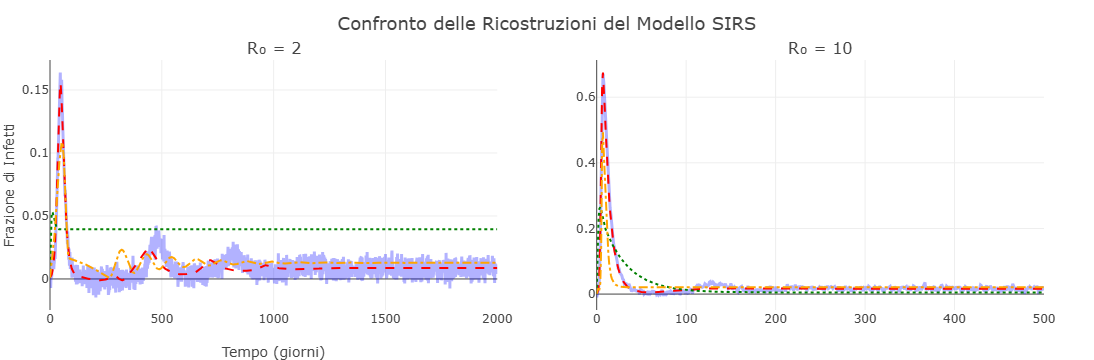

In [81]:
using PlotlyJS
plotlyjs()

# -- Tracce per β = 2
trace_true_1 = PlotlyJS.scatter(x = tsteps, y = noised_traj[2, :], name = "Dati Veri (I)", line = attr(width=3, color="rgba(0, 0, 255, 0.3)"))
trace_resnet_1 = PlotlyJS.scatter(x = tsteps, y = pred_resnet[2, :], mode = "lines", name = "ResNet", line = attr(dash="dash", color="red"))
trace_ode_1 = PlotlyJS.scatter(x = tsteps, y = pred_neural_ode[2, :], mode = "lines", name = "Neural ODE", line = attr(dash="dot", color="green"))
trace_ude_1 = PlotlyJS.scatter(x = tsteps, y = pred_ude[2, :], mode = "lines", name = "UDE", line = attr(dash="dashdot", color="orange"))

# -- Tracce per β = 10
trace_true_2 = PlotlyJS.scatter(x = tsteps_2, y = noised_traj_2[2, :], name = "Dati Veri (I)", line = attr(width=3, color="rgba(0, 0, 255, 0.3)"))
trace_resnet_2 = PlotlyJS.scatter(x = tsteps_2, y = pred_resnet_2[2, :], mode = "lines", name = "ResNet", line = attr(dash="dash", color="red"))
trace_ode_2 = PlotlyJS.scatter(x = tsteps_2, y = pred_neural_ode_2[2, :], mode = "lines", name = "Neural ODE 2", line = attr(dash="dot", color="green"))
trace_ude_2 = PlotlyJS.scatter(x = tsteps_2, y = pred_ude_2[2, :], mode = "lines", name = "UDE 2", line = attr(dash="dashdot", color="orange"))

# -- Crea i subplot
fig = PlotlyJS.make_subplots(rows=1, cols=2, subplot_titles=["R₀ = 2" "R₀ = 10"])

# -- Aggiungi le tracce
add_trace!(fig, trace_true_1, row=1, col=1)
add_trace!(fig, trace_resnet_1, row=1, col=1)
add_trace!(fig, trace_ode_1, row=1, col=1)
add_trace!(fig, trace_ude_1, row=1, col=1)

add_trace!(fig, trace_true_2, row=1, col=2)
add_trace!(fig, trace_resnet_2, row=1, col=2)
add_trace!(fig, trace_ode_2, row=1, col=2)
add_trace!(fig, trace_ude_2, row=1, col=2)

# -- Layout
relayout!(
    fig;
    title_text = "Confronto delle Ricostruzioni del Modello SIRS",
    title_x = 0.5,
    title_font = attr(size=18),
    showlegend = false,
    xaxis_title = "Tempo (giorni)",
    yaxis_title = "Frazione di Infetti",
    template = "plotly_white"
)


# -- Mostra
display(fig)


## 11. Lotka-Volterra (from Rackauckas 2020)